In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch # core python library for neural network based operations
import torchaudio # branch of torch library finetuned for audio processing
import torchaudio.transforms as T # a class from torchaudion library to perform audion processing
import IPython # display and play the audio

- Tensor is a multidimensional container/dataobject of PyTorch library
- As similar to what we have in numpy as numpy arrary

In [4]:
audio, sr = torchaudio.load("/content/Record (online-voice-recorder.com).mp3")

In [11]:
sr

48000

- Mono Audio: One set of number (1 D Sound)
- Stero Audio: Two set of number (2D Sound, This get's you two sides audio in your earphones)

In [7]:
audio

tensor([[ 0.0000e+00, -9.2530e-10, -8.9215e-10,  ..., -1.6655e-08,
         -5.6708e-07,  2.9355e-07]])

In [8]:
audio = audio.squeeze()

In [12]:
audio

tensor([ 0.0000e+00, -9.2530e-10, -8.9215e-10,  ..., -1.6655e-08,
        -5.6708e-07,  2.9355e-07])

In [9]:
IPython.display.Audio(audio, rate=sr)

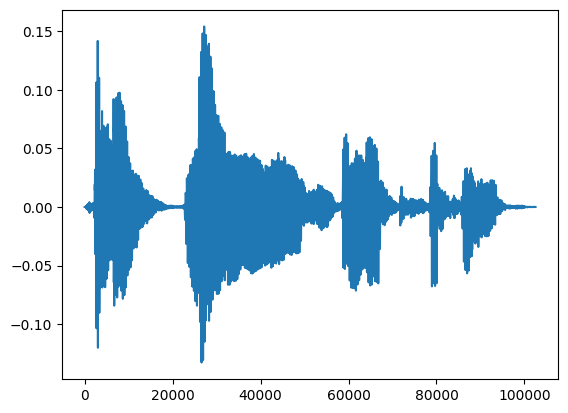

In [10]:
plt.plot(audio)
plt.show()

In [16]:
flute_path = "/content/flute-c-major-single-note_C_major.wav"
violin_path = "/content/356134__mtg__violin-c4.wav"

flute, sr = torchaudio.load(flute_path)
violin, sr = torchaudio.load(violin_path)

flute = flute[:, :int(sr*3.0)]
violin = violin[:, :int(sr*3.0)]


f = flute.squeeze()
v = violin.squeeze()



In [14]:
IPython.display.Audio(v, rate=sr)

In [15]:
IPython.display.Audio(f, rate=sr)

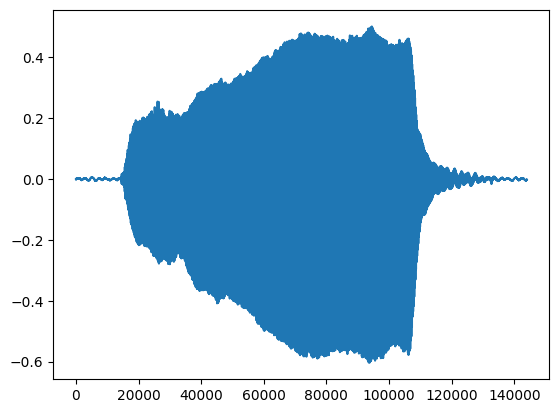

In [17]:
plt.plot(v)
plt.show()

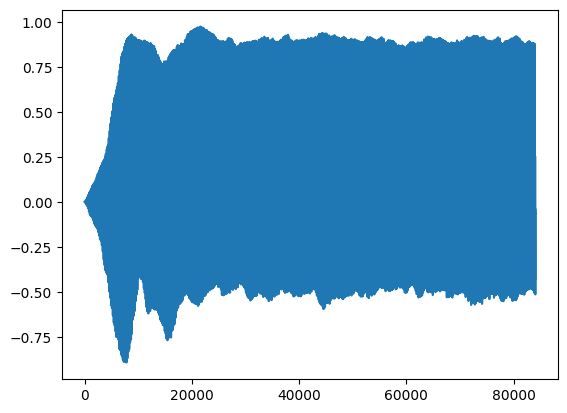

In [18]:
plt.plot(f)
plt.show()

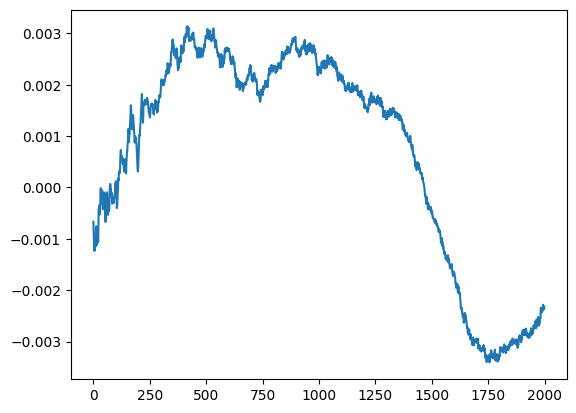

In [20]:
plt.plot(v[0:2000].numpy())
plt.show()

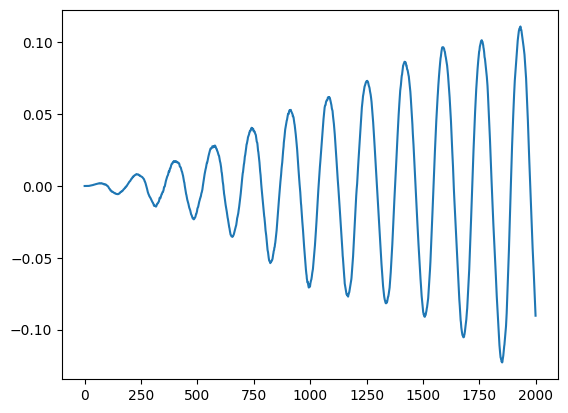

In [21]:
plt.plot(f[0:2000].numpy())
plt.show()

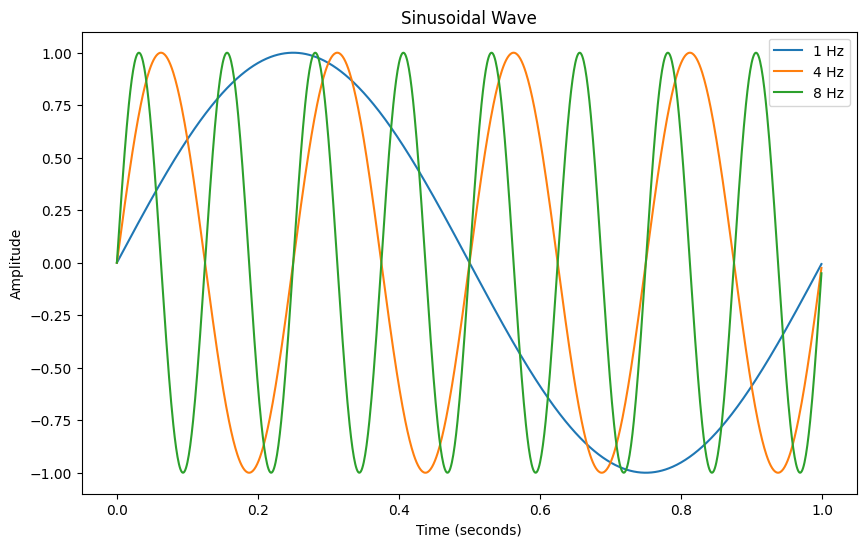

In [22]:
#let's create a dummy audio
t = np.linspace(0,1, 1000, endpoint=False) #time vector
frequenies = [1,4,8]

plt.figure(figsize = (10,6))
for f in frequenies:
  y = np.sin(2*np.pi*f*t)
  plt.plot(t,y, label = f'{f} Hz')

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Sinusoidal Wave")
plt.legend()
plt.show()

- 1 HZs: In 1 sec we see one complete cycle.


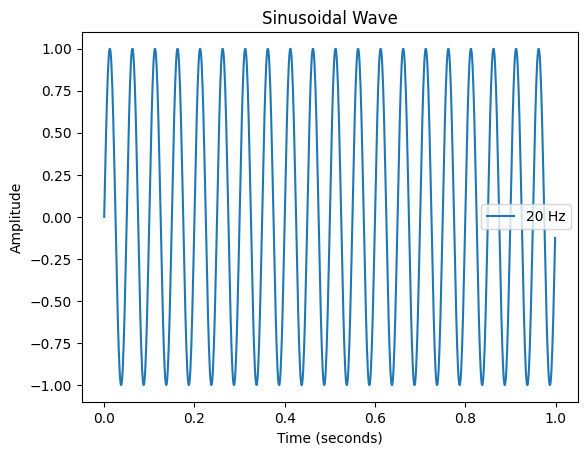

In [23]:
t = np.linspace(0,1, 1000, endpoint=False) #time vector
f =20

y = np.sin(2*np.pi*f*t)
plt.plot(t,y, label = f'{f} Hz')

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Sinusoidal Wave")
plt.legend()
plt.show()

In [25]:
y_fft = np.fft.fft(y)
freqs = np.fft.fftfreq(len(t), d = t[1]-t[0])

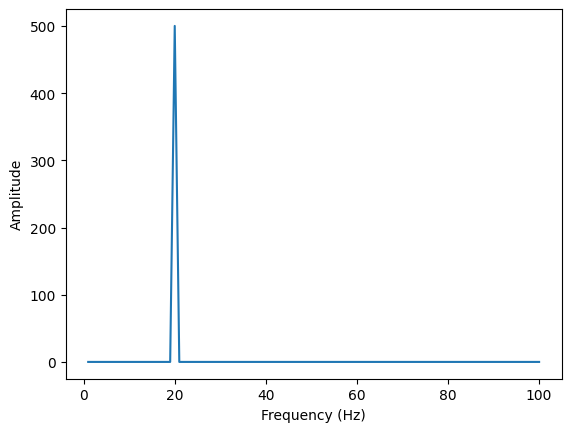

In [28]:
mask = (freqs > 0) & (freqs <= 100)
plt.plot(freqs[mask], np.abs(y_fft[mask]))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

/tmp/ipython-input-205/3685127550.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


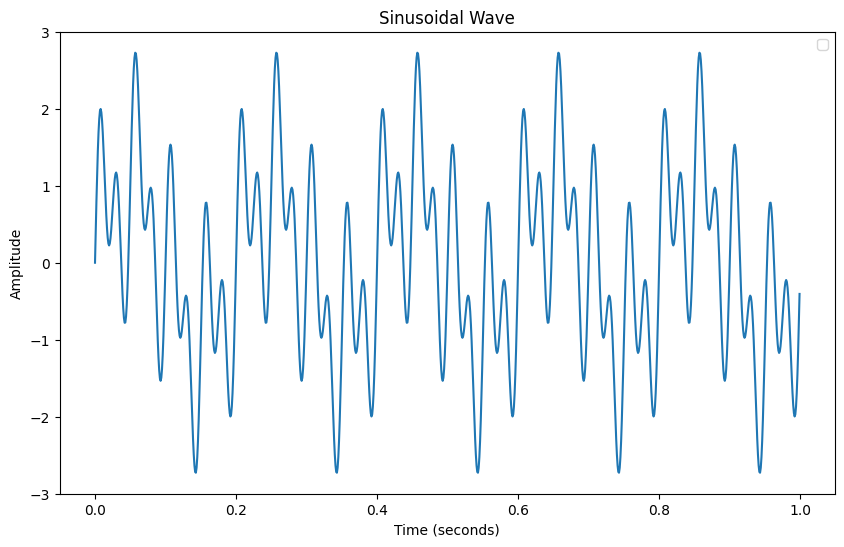

In [29]:
# Dummy Audio with multiple frequencies

t = np.linspace(0,1, 1000, endpoint=False) #time vector
frequenies = [5,20,40]

y = np.sum([np.sin(2*np.pi*f*t) for f in frequenies], axis = 0)

y_fft = np.fft.fft(y)
freqs = np.fft.fftfreq(len(t), d = t[1]-t[0])

plt.figure(figsize = (10,6))
plt.plot(t,y)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Sinusoidal Wave")
plt.legend()
plt.show()

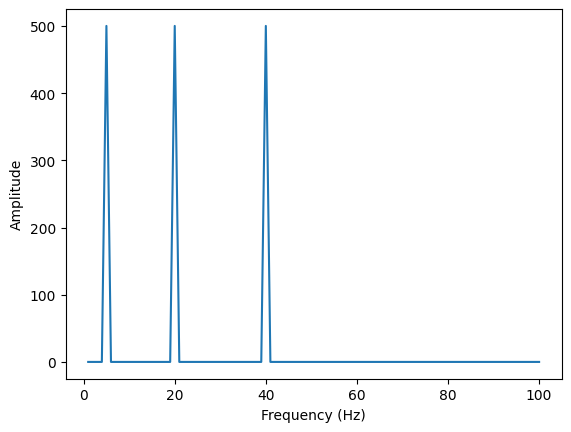

In [30]:
mask = (freqs > 0) & (freqs <= 100)
plt.plot(freqs[mask], np.abs(y_fft[mask]))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

In [36]:
len(audio)

1

/tmp/ipython-input-205/1390519237.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


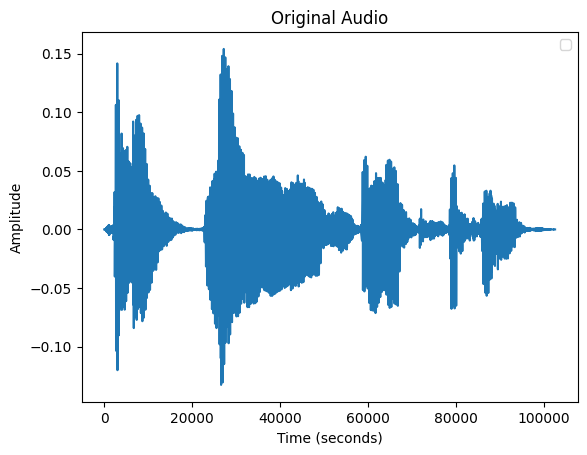

In [46]:
audio, sr = torchaudio.load("/content/Record (online-voice-recorder.com).mp3")
y_fft = np.fft.fft(audio.squeeze())
freqs = np.fft.fftfreq(len(audio.squeeze()), d = 1/sr)

plt.plot(audio.squeeze())
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Original Audio")
plt.legend()
plt.show()


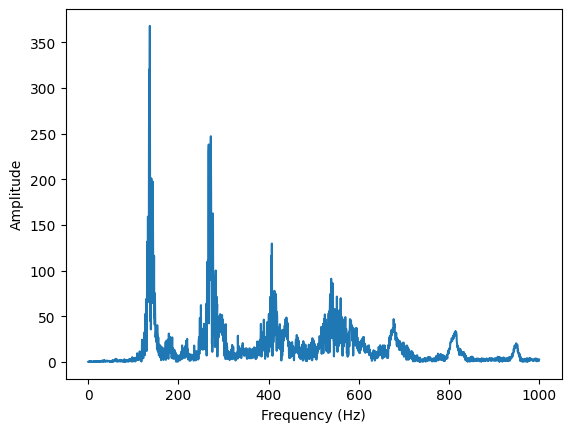

In [47]:
mask = (freqs >= 0) & (freqs <= 1000)
plt.plot(freqs[mask], np.abs(y_fft[mask]))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.show()

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import torch # core python library for neural network based operations
import torchaudio # branch of torch library finetuned for audio processing
import torchaudio.transforms as T # a class from torchaudion library to perform audion processing
import IPython

audio, sr = torchaudio.load("/content/Record (online-voice-recorder.com).mp3")

mel_spe_transform = T.MelSpectrogram(
    sample_rate=sr,
    n_mels = 128,
    n_fft=1024,
    hop_length=128
)

amp_to_db = T.AmplitudeToDB(stype="power", top_db=80)

mel = mel_spe_transform(audio)
spec = amp_to_db(mel)

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


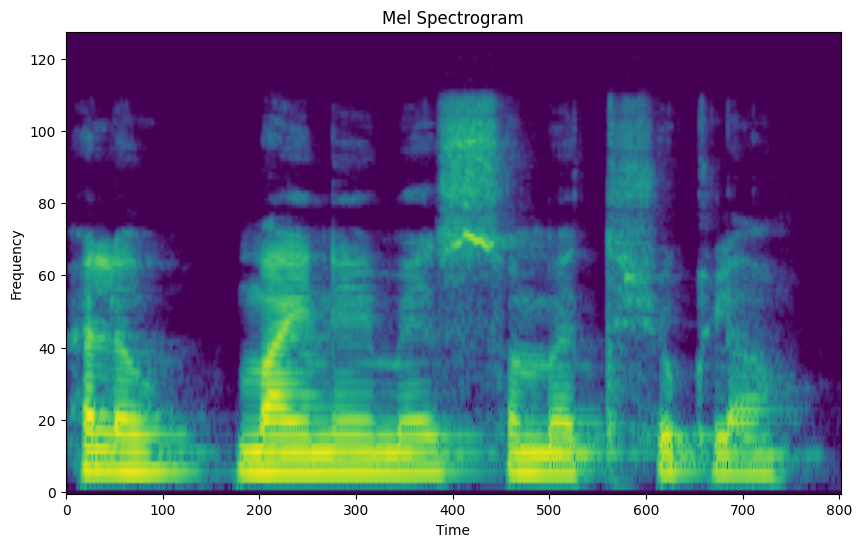

In [54]:
plt.figure(figsize=(10,6))
plt.imshow(spec[0], origin="lower", aspect="auto")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("Mel Spectrogram")
plt.show()

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (513) may be set too low.
  warnings.warn(


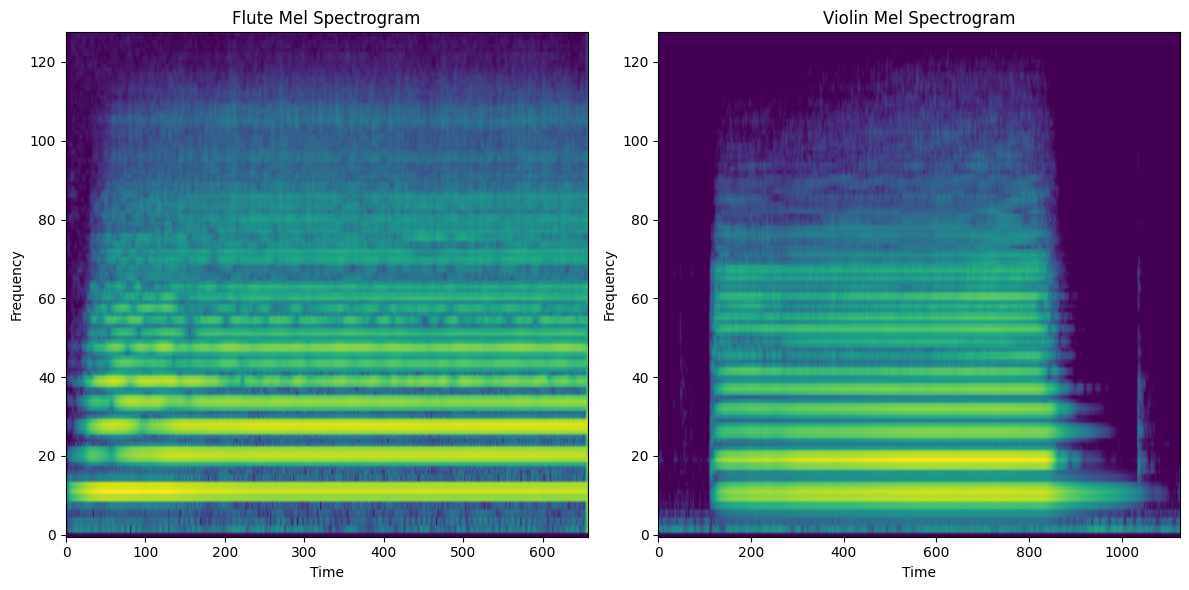

In [62]:
flute_path = "/content/flute-c-major-single-note_C_major.wav"
violin_path = "/content/356134__mtg__violin-c4.wav"

flute, sr = torchaudio.load(flute_path)
violin, sr = torchaudio.load(violin_path)

flute = flute[:, :int(sr*3.0)]
violin = violin[:, :int(sr*3.0)]

mel_spe_transform = T.MelSpectrogram(
    sample_rate=sr,
    n_mels = 128,
    n_fft=1024,
    hop_length=128
)

amp_to_db = T.AmplitudeToDB(stype="power", top_db=80)

flute_mel = mel_spe_transform(flute)
flute_spec = amp_to_db(flute_mel)

violin_mel = mel_spe_transform(violin)
violin_spec = amp_to_db(violin_mel)

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
plt.imshow(flute_spec[0].numpy(), origin="lower", aspect="auto")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("Flute Mel Spectrogram")

plt.subplot(1,2,2)
plt.imshow(violin_spec[0].numpy(), origin="lower", aspect="auto")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.title("Violin Mel Spectrogram")

plt.tight_layout()
plt.show()